# Hadwen Arboretum — Invasive Plant Mapping Analysis

**Clark University · GIS Survey 2024**  
*Annan Shrestha · Bikal Shrestha · Nathan Clark*  
*Sponsor: Professor John Rogan*

---

This notebook presents a complete analysis of the **51,284-cell (2m × 2m)** invasive plant survey conducted at the Hadwen Arboretum in Worcester, MA. Five invasive species were mapped and scored by density (0–3 scale) across the 26-acre urban forest.

| Species | Code |
|---|---|
| Oriental Bittersweet (*Celastrus orbiculatus*) | OB |
| Burning Bush (*Euonymus alatus*) | BB |
| Japanese Knotweed (*Fallopia japonica*) | JK |
| Norway Maple (*Acer platanoides*) | NM |
| Other Invasives | O |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.image as mpimg

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
%matplotlib inline

In [2]:
# ── Constants ──────────────────────────────────────────────────────────────
TOTAL_CELLS   = 51284
INVASIVE_CELLS = 21847
INVASIVE_PCT  = 42.6
NON_INVASIVE_PCT = 57.4

COLORS = {'OB': '#c0392b', 'BB': '#e74c3c', 'JK': '#e67e22', 'NM': '#f39c12', 'O': '#95a5a6'}
DIFFICULTY = {'OB': 1.4, 'JK': 1.5, 'BB': 1.0, 'NM': 0.9, 'O': 0.8}

# ── Load CSVs ───────────────────────────────────────────────────────────────
summary = pd.read_csv('invasive_summary.csv')
density = pd.read_csv('density_details.csv')

summary['coverage_pct'] = summary['Coverage %'].str.rstrip('%').astype(float)
summary['color'] = summary['Code'].map(COLORS)

df = summary.merge(density[['Code', 'High', 'Moderate', 'Low', 'Absent']], on='Code')

print(f"✓ {len(df)} species | {TOTAL_CELLS:,} survey cells | {INVASIVE_PCT}% invasive coverage")
display(
    df[['Species', 'Code', 'Cells Present', 'Coverage %', 'Avg Density', 'High', 'Moderate', 'Low']]
    .set_index('Code')
)

✓ 5 species | 51,284 survey cells | 42.6% invasive coverage


,Species,Cells Present,Coverage %,Avg Density,High,Moderate,Low
Code,,,,,,,
BB,Burning Bush,8967,17.5%,0.38,3137,4152,1678
OB,Oriental Bittersweet,12890,25.1%,0.54,4417,5812,2661
JK,Japanese Knotweed,3959,7.7%,0.20,2654,1059,246
NM,Norway Maple,1216,2.4%,0.05,227,675,314
O,Other Invasives,315,0.6%,0.02,278,20,17


## 1. Species Coverage

How many survey cells contain each invasive species, and what percentage of the arboretum does each cover?

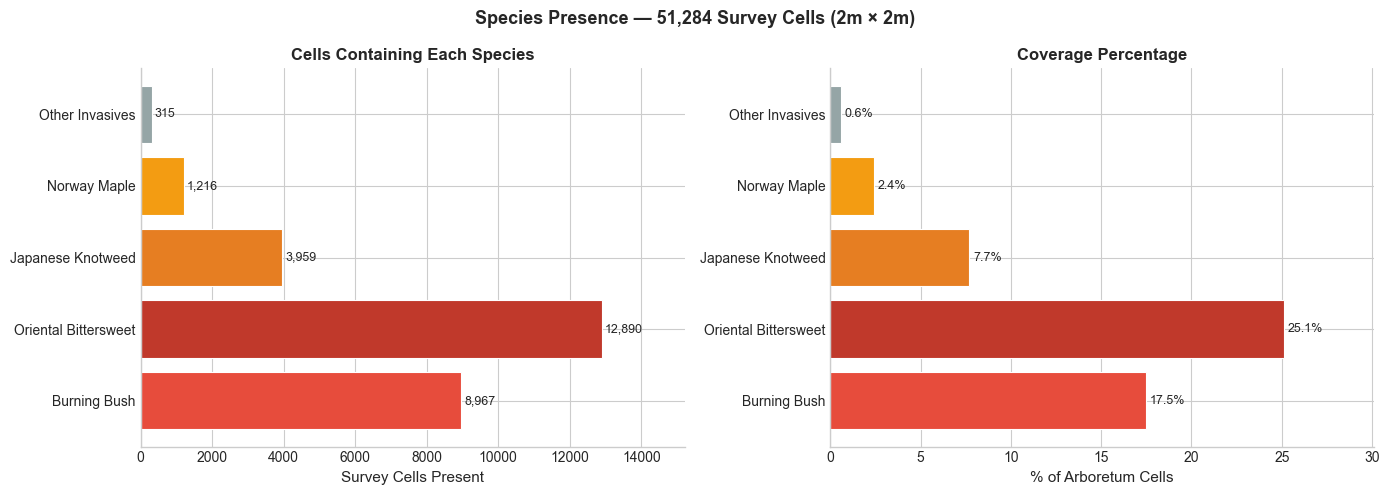


Total invasive cells: 21,847 / 51,284  →  42.6% of the arboretum


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_list = [COLORS[c] for c in df['Code']]

# Cells present
bars1 = ax1.barh(df['Species'], df['Cells Present'], color=colors_list, edgecolor='white', linewidth=0.8)
ax1.set_xlabel('Survey Cells Present', fontsize=11)
ax1.set_title('Cells Containing Each Species', fontsize=12, fontweight='bold')
for bar, n in zip(bars1, df['Cells Present']):
    ax1.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
             f'{n:,}', va='center', fontsize=9)
ax1.set_xlim(0, df['Cells Present'].max() * 1.18)

# Coverage %
bars2 = ax2.barh(df['Species'], df['coverage_pct'], color=colors_list, edgecolor='white', linewidth=0.8)
ax2.set_xlabel('% of Arboretum Cells', fontsize=11)
ax2.set_title('Coverage Percentage', fontsize=12, fontweight='bold')
for bar, pct in zip(bars2, df['coverage_pct']):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f'{pct}%', va='center', fontsize=9)
ax2.set_xlim(0, df['coverage_pct'].max() * 1.2)

plt.suptitle('Species Presence — 51,284 Survey Cells (2m × 2m)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal invasive cells: {INVASIVE_CELLS:,} / {TOTAL_CELLS:,}  →  {INVASIVE_PCT}% of the arboretum")

## 2. Density Distribution

Each cell is rated 0–3: **0** = Absent · **1** = Low · **2** = Moderate · **3** = High/Dominant

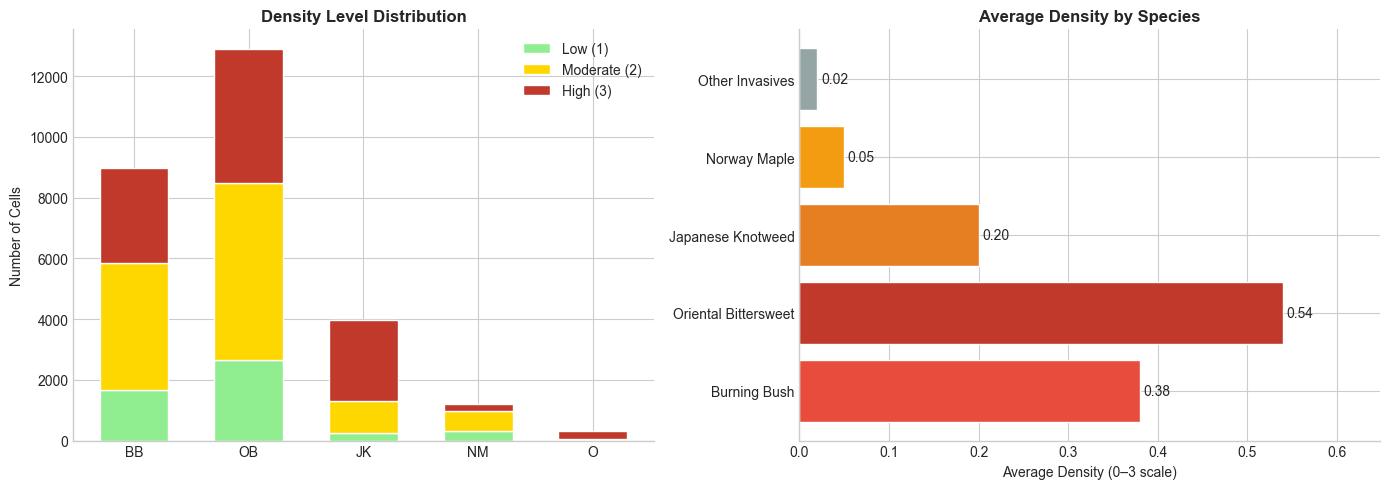

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x     = np.arange(len(df))
width = 0.6
low   = df['Low'].values
mod   = df['Moderate'].values
high  = df['High'].values

ax1.bar(x, low,  width, label='Low (1)',      color='#90ee90', edgecolor='white')
ax1.bar(x, mod,  width, bottom=low,            label='Moderate (2)', color='#ffd700', edgecolor='white')
ax1.bar(x, high, width, bottom=low + mod,      label='High (3)',     color='#c0392b', edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(df['Code'])
ax1.set_ylabel('Number of Cells')
ax1.set_title('Density Level Distribution', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

bars = ax2.barh(df['Species'], df['Avg Density'], color=colors_list, edgecolor='white')
ax2.set_xlabel('Average Density (0–3 scale)')
ax2.set_title('Average Density by Species', fontsize=12, fontweight='bold')
for bar, val in zip(bars, df['Avg Density']):
    ax2.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=10)
ax2.set_xlim(0, df['Avg Density'].max() * 1.2)

plt.tight_layout()
plt.show()

## 3. Species Composition & Overall Coverage

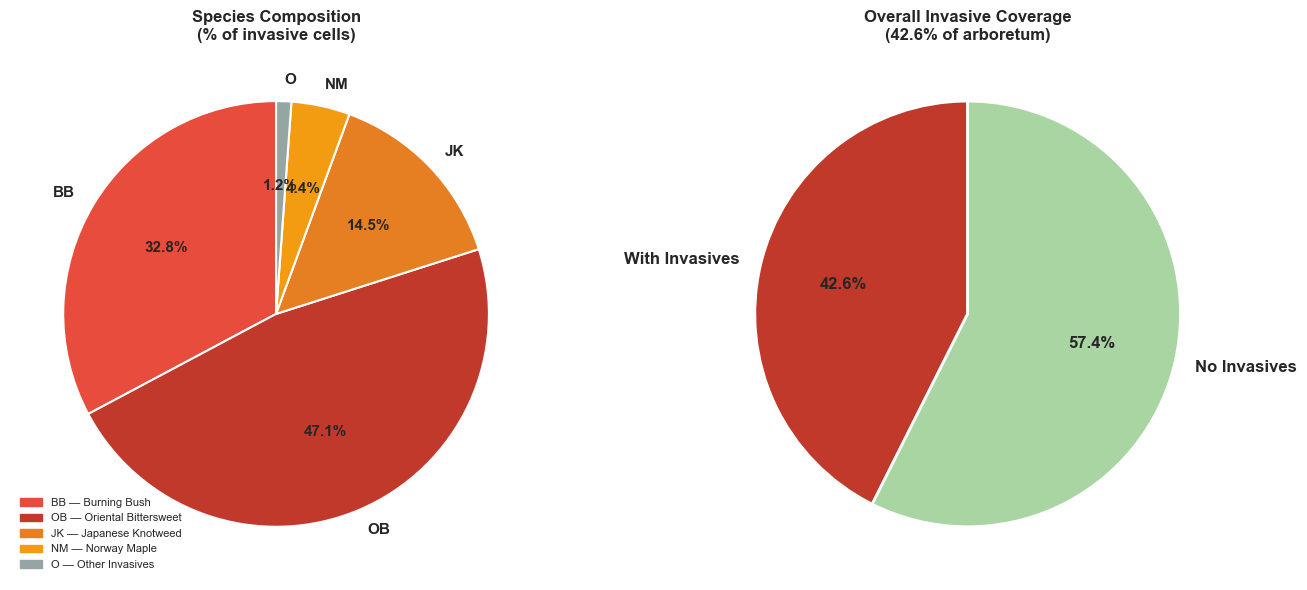

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Species composition — share of invasive cells
total_inv = df['Cells Present'].sum()
comp_pct  = df['Cells Present'] / total_inv * 100

ax1.pie(
    comp_pct,
    labels=df['Code'],
    colors=[COLORS[c] for c in df['Code']],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontweight': 'bold', 'fontsize': 11},
)
ax1.set_title('Species Composition\n(% of invasive cells)', fontsize=12, fontweight='bold')
legend_handles = [
    mpatches.Patch(color=COLORS[row['Code']], label=f"{row['Code']} — {row['Species']}")
    for _, row in df.iterrows()
]
ax1.legend(handles=legend_handles, loc='lower left', fontsize=8, framealpha=0.9)

# Overall invasive coverage
ax2.pie(
    [INVASIVE_PCT, NON_INVASIVE_PCT],
    labels=['With Invasives', 'No Invasives'],
    colors=['#c0392b', '#a8d5a2'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontweight': 'bold', 'fontsize': 12},
)
ax2.set_title('Overall Invasive Coverage\n(42.6% of arboretum)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. GIS Density Maps

Spatial density maps produced in ArcGIS — each cell is colored by density level (0–3). Red areas indicate high-density invasive presence.

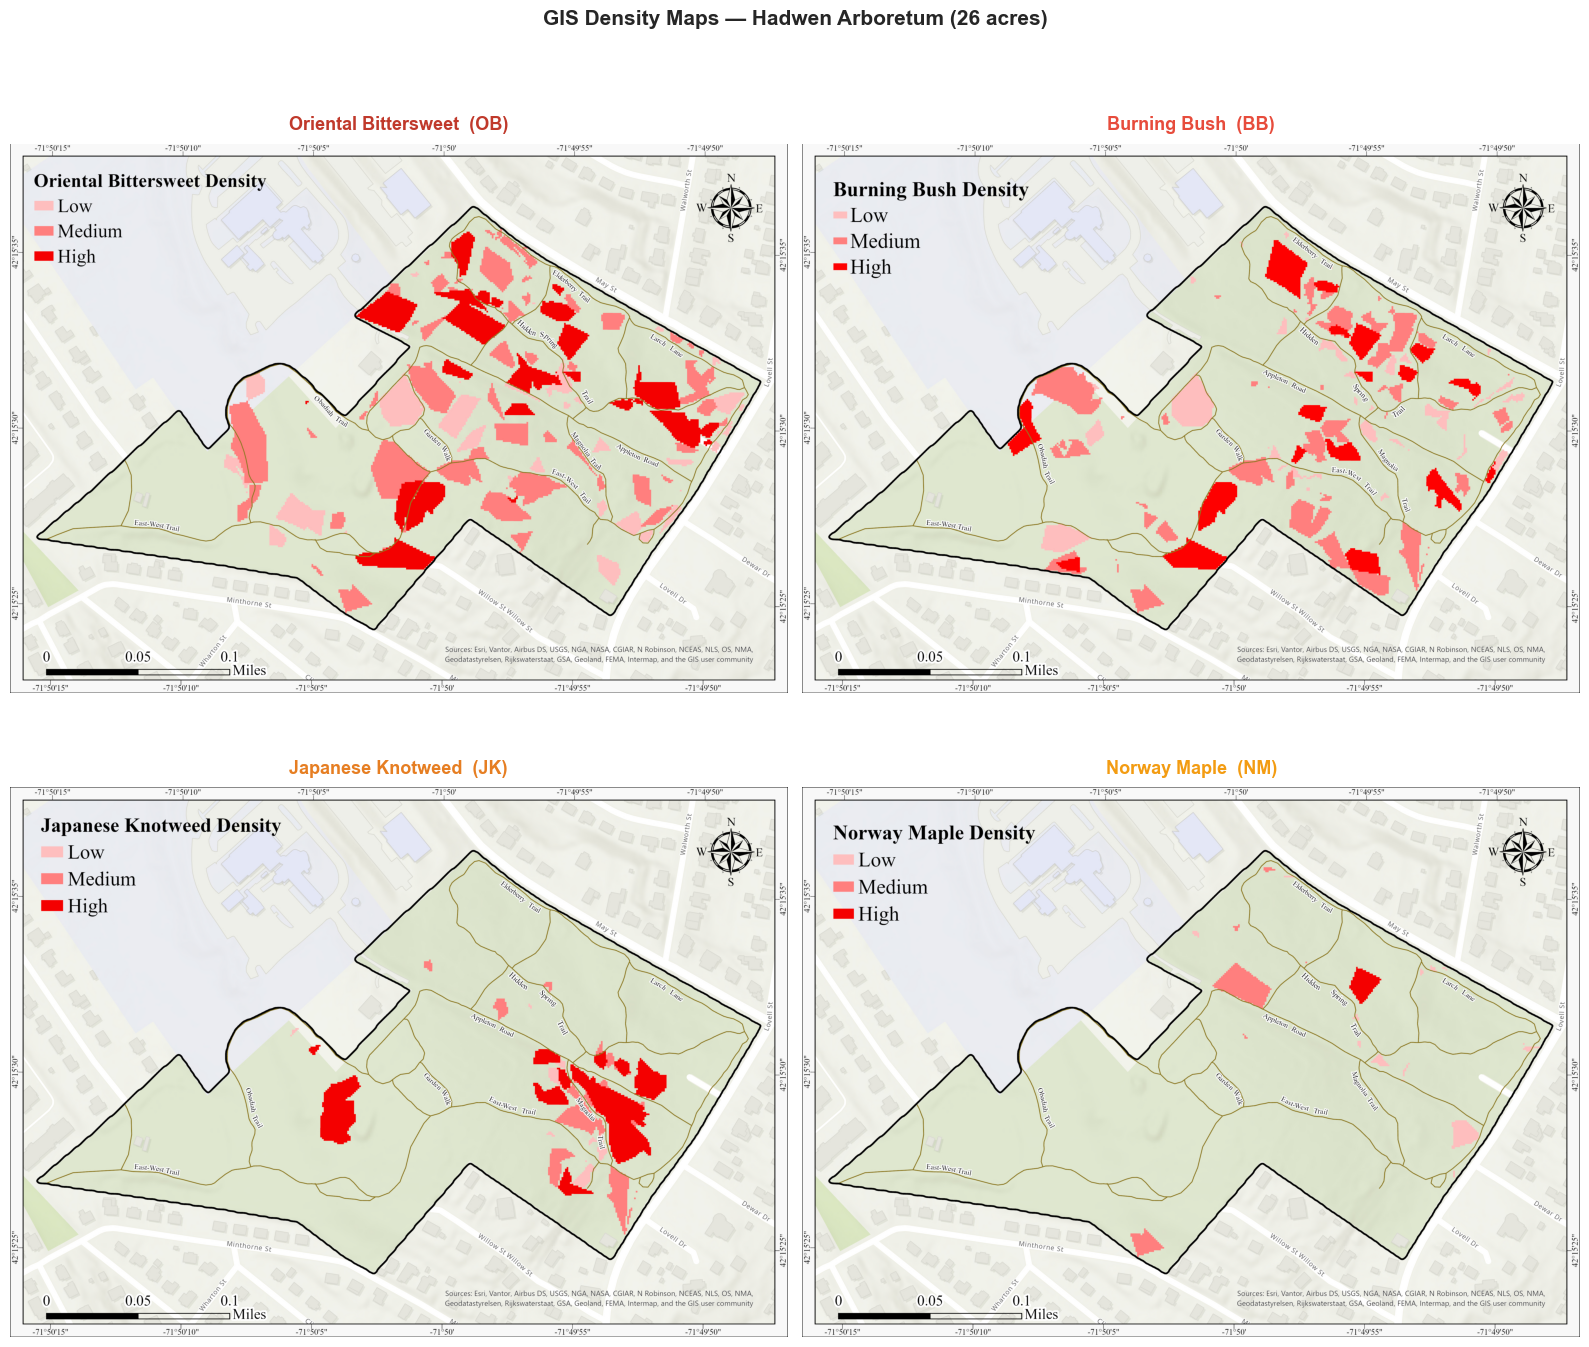

In [6]:
map_files = [
    ('OB', 'static/images/OBLayout.jpg', 'Oriental Bittersweet'),
    ('BB', 'static/images/BBLayout.jpg', 'Burning Bush'),
    ('JK', 'static/images/JKLayout.jpg', 'Japanese Knotweed'),
    ('NM', 'static/images/NMLayout.jpg', 'Norway Maple'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (code, path, name) in zip(axes, map_files):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.set_title(f'{name}  ({code})', fontsize=13, fontweight='bold', color=COLORS[code], pad=10)
    ax.axis('off')

plt.suptitle('GIS Density Maps — Hadwen Arboretum (26 acres)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. New Analysis

Three composite analyses extending the original poster findings:

| Analysis | Formula |
|---|---|
| **Threat Index** | `(coverage × 0.4) + (avg_density/3 × 0.4) + (high_cells/total × 0.2)` × 100 |
| **Severity Heatmap** | Color-coded table — white (low) → dark red (high) within each metric column |
| **Management Effort** | `cells_present × avg_density × difficulty_multiplier`, normalized to 100% |

Difficulty multipliers reflect removal complexity: JK = 1.5 (rhizome system), OB = 1.4 (vine regrowth), BB = 1.0, NM = 0.9.

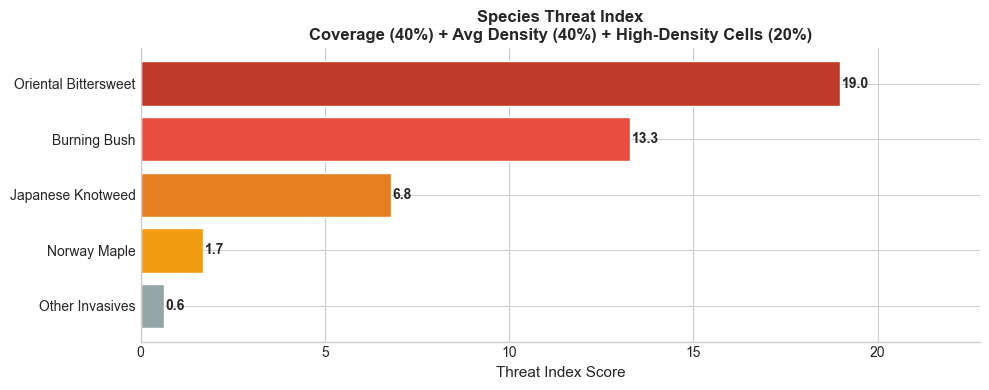

Threat scores (high → low):
             Species Code  threat_score
Oriental Bittersweet   OB         18.98
        Burning Bush   BB         13.28
   Japanese Knotweed   JK          6.79
        Norway Maple   NM          1.70
     Other Invasives    O          0.62


In [7]:
# ── Threat Index ────────────────────────────────────────────────────────────
def compute_threat(row):
    coverage = row['Cells Present'] / TOTAL_CELLS
    avg_den  = row['Avg Density'] / 3
    high_pct = row['High'] / TOTAL_CELLS
    return round(((coverage * 0.4) + (avg_den * 0.4) + (high_pct * 0.2)) * 100, 2)

df['threat_score'] = df.apply(compute_threat, axis=1)
df_t = df.sort_values('threat_score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_t['Species'], df_t['threat_score'],
               color=[COLORS[c] for c in df_t['Code']], edgecolor='white')
ax.set_xlabel('Threat Index Score', fontsize=11)
ax.set_title('Species Threat Index\nCoverage (40%) + Avg Density (40%) + High-Density Cells (20%)',
             fontsize=12, fontweight='bold')
for bar, score in zip(bars, df_t['threat_score']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, df['threat_score'].max() * 1.2)
plt.tight_layout()
plt.show()

print("Threat scores (high → low):")
print(df[['Species', 'Code', 'threat_score']].sort_values('threat_score', ascending=False).to_string(index=False))

In [8]:
# ── Severity Heatmap ─────────────────────────────────────────────────────────
def severity_color(value, max_value):
    if max_value == 0:
        return '#ffffff'
    ratio = min(value / max_value, 1.0)
    r = int(255 - ratio * (255 - 192))
    g = int(255 - ratio * (255 - 57))
    b = int(255 - ratio * (255 - 43))
    return f'#{r:02x}{g:02x}{b:02x}'

cols       = ['coverage_pct', 'Avg Density', 'High', 'Moderate', 'Low']
col_labels = ['Coverage %',   'Avg Density', 'High-Density Cells', 'Moderate Cells', 'Low Cells']

def fmt(val):
    if isinstance(val, float) and val < 100:
        return f'{val:.2f}'
    return f'{int(val):,}'

rows_html = []
for _, row in df.sort_values('threat_score', ascending=False).iterrows():
    dot = f'<span style="display:inline-block;width:10px;height:10px;border-radius:50%;background:{COLORS[row["Code"]]};margin-right:6px"></span>'
    tds = f'<td style="padding:8px 12px;white-space:nowrap">{dot}{row["Species"]}</td>'
    for col in cols:
        val = row[col]; mx = df[col].max()
        bg = severity_color(val, mx)
        tds += f'<td style="background:{bg};padding:8px 12px;text-align:right;font-weight:500">{fmt(val)}</td>'
    rows_html.append(f'<tr>{tds}</tr>')

header = '<tr style="background:#2d5a27;color:white">' +     '<th style="padding:10px 12px;text-align:left">Species</th>' +     ''.join(f'<th style="padding:10px 12px;text-align:right">{lbl}</th>' for lbl in col_labels) +     '</tr>'

display(HTML(
    '<h4 style="font-family:sans-serif;margin-bottom:6px">Severity Heatmap — white (low) → dark red (high)</h4>'
    + f'<table style="border-collapse:collapse;font-family:sans-serif;font-size:13px">{header}{"".join(rows_html)}</table>'
))

Species,Coverage %,Avg Density,High-Density Cells,Moderate Cells,Low Cells
Oriental Bittersweet,25.10,0.54,"4,417","5,812","2,661"
Burning Bush,17.50,0.38,"3,137","4,152","1,678"
Japanese Knotweed,7.70,0.20,"2,654","1,059",246
Norway Maple,2.40,0.05,227,675,314
Other Invasives,0.60,0.02,278,20,17


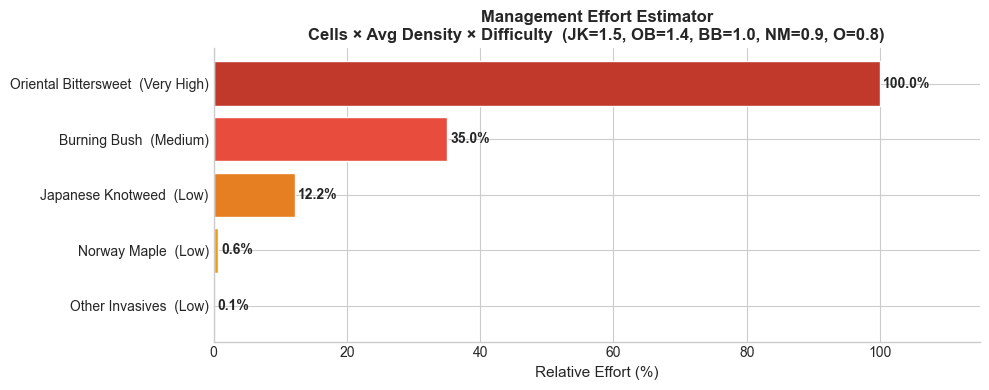

In [9]:
# ── Management Effort Estimator ──────────────────────────────────────────────
df['effort_raw'] = df.apply(
    lambda r: r['Cells Present'] * r['Avg Density'] * DIFFICULTY[r['Code']], axis=1
)
max_effort = df['effort_raw'].max()
df['effort_pct'] = (df['effort_raw'] / max_effort * 100).round(1)

def effort_tier(pct):
    if pct >= 75: return 'Very High'
    if pct >= 40: return 'High'
    if pct >= 15: return 'Medium'
    return 'Low'

df['effort_tier'] = df['effort_pct'].map(effort_tier)
df_e = df.sort_values('effort_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
labels = [f"{row['Species']}  ({row['effort_tier']})" for _, row in df_e.iterrows()]
bars   = ax.barh(labels, df_e['effort_pct'], color=[COLORS[c] for c in df_e['Code']], edgecolor='white')
ax.set_xlabel('Relative Effort (%)', fontsize=11)
ax.set_title('Management Effort Estimator\nCells × Avg Density × Difficulty  (JK=1.5, OB=1.4, BB=1.0, NM=0.9, O=0.8)',
             fontsize=12, fontweight='bold')
for bar, pct in zip(bars, df_e['effort_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

## Summary

| Metric | Value |
|--------|-------|
| Total survey cells | 51,284 (2m × 2m grid) |
| Arboretum area | ~26 acres |
| Cells with any invasive | 21,847 (42.6%) |
| Highest-coverage species | Oriental Bittersweet — 25.1% |
| Highest threat index | Oriental Bittersweet |
| Most effort to remove | Oriental Bittersweet |

**Key findings:**
- **OB** is the dominant threat across all metrics: coverage, density, threat index, and removal effort
- **BB** is widespread (17.5%) but mechanically manageable (difficulty 1.0)
- **JK** covers only 7.7% but has the highest difficulty multiplier (1.5) due to deep rhizome regrowth requiring 6–10 years of treatment
- **57.4%** of the arboretum is currently invasive-free — early preventive action can protect this land

**Recommended priorities:** Target OB + JK dense patches near trails first; pair mechanical removal with native understory planting to suppress regrowth.